# 01 — EDA: Default Rate by Segment and Data Quality

UCI "Default of Credit Card Clients" (id 350, CC BY 4.0), 30,000 accounts. See `../data/README.md`
for the source and `../.ai/PROJECT_SPEC.md` for the project brief.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path("..", "src").resolve()))

import matplotlib.pyplot as plt
from credit_risk import data

df = data.load_raw()
print(f"{len(df):,} rows, {df.shape[1]} columns")
df.head()

30,000 rows, 25 columns


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default_payment_next_month
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


## Data quality

In [2]:
missing = df.isna().sum()
missing = missing[missing > 0]
print("Missing values per column:")
print(missing if len(missing) else "none")
print()
print("Duplicate IDs:", df["ID"].duplicated().sum())
print("Duplicate full rows:", df.duplicated().sum())

Missing values per column:
none

Duplicate IDs: 0
Duplicate full rows: 0


In [3]:
# EDUCATION and MARRIAGE both have undocumented category codes (the UCI
# codebook only defines EDUCATION 1-4 and MARRIAGE 1-3). This is a known
# quirk of this dataset, not a data-entry bug we introduced -- flagged here
# rather than silently recoded, since it affects the fairness audit's
# EDUCATION/MARRIAGE groupings in 02_models.ipynb.
print("EDUCATION value counts (1-4 documented, 0/5/6 undocumented):")
print(df["EDUCATION"].value_counts().sort_index())
print()
print("MARRIAGE value counts (1-3 documented, 0 undocumented):")
print(df["MARRIAGE"].value_counts().sort_index())

EDUCATION value counts (1-4 documented, 0/5/6 undocumented):
EDUCATION
0       14
1    10585
2    14030
3     4917
4      123
5      280
6       51
Name: count, dtype: int64

MARRIAGE value counts (1-3 documented, 0 undocumented):
MARRIAGE
0       54
1    13659
2    15964
3      323
Name: count, dtype: int64


## Default rate by segment

In [4]:
from credit_risk.fairness import bucket_age

overall_rate = df[data.TARGET].mean()
print(f"Overall default rate: {overall_rate:.1%}")

df["age_band"] = bucket_age(df["AGE"])

for col in ["SEX", "EDUCATION", "MARRIAGE", "age_band"]:
    print(f"\n-- {col} --")
    print(df.groupby(col, observed=True)[data.TARGET].agg(n="count", default_rate="mean"))

Overall default rate: 22.1%

-- SEX --
         n  default_rate
SEX                     
1    11888      0.241672
2    18112      0.207763

-- EDUCATION --
               n  default_rate
EDUCATION                     
0             14      0.000000
1          10585      0.192348
2          14030      0.237349
3           4917      0.251576
4            123      0.056911
5            280      0.064286
6             51      0.156863

-- MARRIAGE --
              n  default_rate
MARRIAGE                     
0            54      0.092593
1         13659      0.234717
2         15964      0.209283
3           323      0.260062

-- age_band --
              n  default_rate
age_band                     
<=25       3871      0.266598
26-35     12938      0.198253
36-45      8522      0.218376
46-55      3825      0.249412
56+         844      0.265403


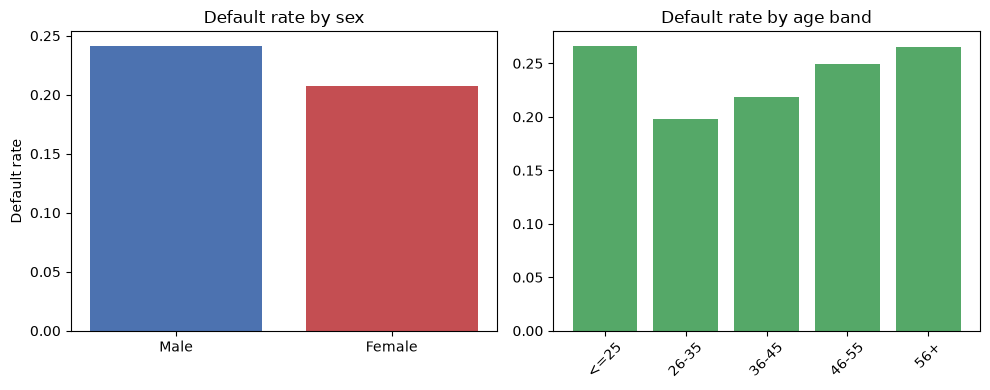

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

sex_rates = df.groupby("SEX")[data.TARGET].mean()
axes[0].bar(["Male", "Female"], sex_rates.values, color=["#4C72B0", "#C44E52"])
axes[0].set_title("Default rate by sex")
axes[0].set_ylabel("Default rate")

age_rates = df.groupby("age_band", observed=True)[data.TARGET].mean()
axes[1].bar(age_rates.index.astype(str), age_rates.values, color="#55A868")
axes[1].set_title("Default rate by age band")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

## Takeaways for modeling

- No missing values or duplicate rows/IDs.
- `EDUCATION` and `MARRIAGE` carry undocumented category codes (0, 5, 6 and 0
  respectively) - kept as-is since they're a real property of the source data,
  but noted so the fairness-audit group tables in `02_models.ipynb` aren't
  misread as a data-cleaning miss.
- Default rate varies meaningfully by sex, education, marriage, and age band -
  exactly the segments the fairness audit needs to check, since `SEX`, `AGE`,
  `MARRIAGE`, and `EDUCATION` are excluded from model features but used for
  the audit (see `../.ai/PROJECT_SPEC.md`).